<a href="https://colab.research.google.com/github/kotaamulyareddy/Data-Profiling-and-Quality-Assessment/blob/main/ValueMomentum_AmulyaCaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 1: Data Profiling and Quality Assessment

## Objective

The objective of this case study is to understand the structure and quality of the Agency Performance dataset before performing further business analysis.

The analysis focuses on:

- Understanding the dataset structure
- Identifying missing values
- Detecting duplicate records
- Identifying hidden missing values
- Checking categorical data consistency
- Understanding numeric data distributions
- Identifying important data quality risks

**1.Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

**2.Load Dataset**

In [ ]:
df=pd.read_csv("/content/finalapi.csv.zip")
print("Dataset loaded successfully!")

Dataset loaded successfully!


**3.Dataset Overview**

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Number of Rows: 213328
Number of Columns: 49

Column Names:
['AGENCY_ID', 'PRIMARY_AGENCY_ID', 'PROD_ABBR', 'PROD_LINE', 'STATE_ABBR', 'STAT_PROFILE_DATE_YEAR', 'RETENTION_POLY_QTY', 'POLY_INFORCE_QTY', 'PREV_POLY_INFORCE_QTY', 'NB_WRTN_PREM_AMT', 'WRTN_PREM_AMT', 'PREV_WRTN_PREM_AMT', 'PRD_ERND_PREM_AMT', 'PRD_INCRD_LOSSES_AMT', 'MONTHS', 'RETENTION_RATIO', 'LOSS_RATIO', 'LOSS_RATIO_3YR', 'GROWTH_RATE_3YR', 'AGENCY_APPOINTMENT_YEAR', 'ACTIVE_PRODUCERS', 'MAX_AGE', 'MIN_AGE', 'VENDOR_IND', 'VENDOR', 'PL_START_YEAR', 'PL_END_YEAR', 'COMMISIONS_START_YEAR', 'COMMISIONS_END_YEAR', 'CL_START_YEAR', 'CL_END_YEAR', 'ACTIVITY_NOTES_START_YEAR', 'ACTIVITY_NOTES_END_YEAR', 'CL_BOUND_CT_MDS', 'CL_QUO_CT_MDS', 'CL_BOUND_CT_SBZ', 'CL_QUO_CT_SBZ', 'CL_BOUND_CT_eQT', 'CL_QUO_CT_eQT', 'PL_BOUND_CT_ELINKS', 'PL_QUO_CT_ELINKS', 'PL_BOUND_CT_PLRANK', 'PL_QUO_CT_PLRANK', 'PL_BOUND_CT_eQTte', 'PL_QUO_CT_eQTte', 'PL_BOUND_CT_APPLIED', 'PL_QUO_CT_APPLIED', 'PL_BOUND_CT_TRANSACTNOW', 'PL_QUO_CT_TRANSACTNOW']

**4. Schema Validation**

In [ ]:
# Identify numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Identify categorical columns
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumeric Columns:")
print(numeric_columns)

Number of Numeric Columns: 44
Number of Categorical Columns: 5

Categorical Columns:
['PROD_ABBR', 'PROD_LINE', 'STATE_ABBR', 'VENDOR_IND', 'VENDOR']

Numeric Columns:
['AGENCY_ID', 'PRIMARY_AGENCY_ID', 'STAT_PROFILE_DATE_YEAR', 'RETENTION_POLY_QTY', 'POLY_INFORCE_QTY', 'PREV_POLY_INFORCE_QTY', 'NB_WRTN_PREM_AMT', 'WRTN_PREM_AMT', 'PREV_WRTN_PREM_AMT', 'PRD_ERND_PREM_AMT', 'PRD_INCRD_LOSSES_AMT', 'MONTHS', 'RETENTION_RATIO', 'LOSS_RATIO', 'LOSS_RATIO_3YR', 'GROWTH_RATE_3YR', 'AGENCY_APPOINTMENT_YEAR', 'ACTIVE_PRODUCERS', 'MAX_AGE', 'MIN_AGE', 'PL_START_YEAR', 'PL_END_YEAR', 'COMMISIONS_START_YEAR', 'COMMISIONS_END_YEAR', 'CL_START_YEAR', 'CL_END_YEAR', 'ACTIVITY_NOTES_START_YEAR', 'ACTIVITY_NOTES_END_YEAR', 'CL_BOUND_CT_MDS', 'CL_QUO_CT_MDS', 'CL_BOUND_CT_SBZ', 'CL_QUO_CT_SBZ', 'CL_BOUND_CT_eQT', 'CL_QUO_CT_eQT', 'PL_BOUND_CT_ELINKS', 'PL_QUO_CT_ELINKS', 'PL_BOUND_CT_PLRANK', 'PL_QUO_CT_PLRANK', 'PL_BOUND_CT_eQTte', 'PL_QUO_CT_eQTte', 'PL_BOUND_CT_APPLIED', 'PL_QUO_CT_APPLIED', 'PL_BOU

**5. Create the Data Dictionary**

In [ ]:
data_dictionary = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(2).values,
    "Unique Values": df.nunique().values
})

data_dictionary

,Column Name,Data Type,Missing Values,Missing %,Unique Values
0,AGENCY_ID,int64,0,0.0,1623
1,PRIMARY_AGENCY_ID,int64,0,0.0,588
2,PROD_ABBR,object,0,0.0,28
3,PROD_LINE,object,0,0.0,2
4,STATE_ABBR,object,0,0.0,6
5,STAT_PROFILE_DATE_YEAR,int64,0,0.0,11
6,RETENTION_POLY_QTY,int64,0,0.0,4952
7,POLY_INFORCE_QTY,int64,0,0.0,5190
8,PREV_POLY_INFORCE_QTY,int64,0,0.0,5327
9,NB_WRTN_PREM_AMT,float64,0,0.0,36088


**6. Missing Value Analysis**

In [ ]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
AGENCY_ID,0,0.0
PRIMARY_AGENCY_ID,0,0.0
PROD_ABBR,0,0.0
PROD_LINE,0,0.0
STATE_ABBR,0,0.0
STAT_PROFILE_DATE_YEAR,0,0.0
RETENTION_POLY_QTY,0,0.0
POLY_INFORCE_QTY,0,0.0
PREV_POLY_INFORCE_QTY,0,0.0
NB_WRTN_PREM_AMT,0,0.0


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


**7. Hidden Missing Values**

In [ ]:
# Check for the hidden missing-value code 99999

sentinel_counts = (df == 99999).sum()

sentinel_counts = sentinel_counts[
    sentinel_counts > 0
].sort_values(ascending=False)

print("Columns containing 99999:")
print(sentinel_counts)

Columns containing 99999:
ACTIVITY_NOTES_END_YEAR      209258
PL_END_YEAR                  209174
COMMISIONS_END_YEAR          205604
CL_END_YEAR                  204760
ACTIVITY_NOTES_START_YEAR    171536
COMMISIONS_START_YEAR        141937
RETENTION_RATIO              129978
CL_START_YEAR                129311
CL_QUO_CT_SBZ                 98689
CL_BOUND_CT_SBZ               98689
CL_QUO_CT_eQT                 98689
CL_BOUND_CT_eQT               98689
CL_QUO_CT_MDS                 98689
CL_BOUND_CT_MDS               98689
GROWTH_RATE_3YR               91067
PL_START_YEAR                 82200
PL_BOUND_CT_PLRANK            57444
PL_QUO_CT_PLRANK              57444
PL_BOUND_CT_eQTte             57444
PL_QUO_CT_eQTte               57444
PL_BOUND_CT_TRANSACTNOW       57444
PL_QUO_CT_TRANSACTNOW         57444
PL_BOUND_CT_ELINKS            57444
PL_QUO_CT_ELINKS              57444
PL_BOUND_CT_APPLIED           57444
PL_QUO_CT_APPLIED             57444
LOSS_RATIO                    51232
LO

**8. Convert Sentinel Values to Missing Values**

In [ ]:
df_clean = df.copy()

df_clean = df_clean.replace(
    [99999, -99999],
    np.nan
)

print("Sentinel values converted to NaN.")

Sentinel values converted to NaN.


In [ ]:
clean_missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage": (
        df_clean.isnull().mean() * 100
    ).round(2)
})

clean_missing.sort_values(
    "Missing Percentage",
    ascending=False
)


,Missing Count,Missing Percentage
ACTIVITY_NOTES_END_YEAR,209258,98.09
PL_END_YEAR,209174,98.05
COMMISIONS_END_YEAR,205604,96.38
CL_END_YEAR,204760,95.98
ACTIVITY_NOTES_START_YEAR,171536,80.41
COMMISIONS_START_YEAR,141937,66.53
RETENTION_RATIO,129978,60.93
CL_START_YEAR,129311,60.62
CL_BOUND_CT_MDS,98689,46.26
CL_BOUND_CT_eQT,98689,46.26


**9. Duplicate Records**

In [ ]:
duplicate_count = df_clean.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)

duplicate_percentage = (
    duplicate_count / len(df_clean) * 100
)

print(
    "Duplicate Percentage:",
    round(duplicate_percentage, 2),
    "%"
)

Number of Duplicate Records: 0
Duplicate Percentage: 0.0 %


**10. Clean Categorical Columns**

In [ ]:
categorical_columns = df_clean.select_dtypes(
    include=["object", "string", "category"]
).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['PROD_ABBR', 'PROD_LINE', 'STATE_ABBR', 'VENDOR_IND', 'VENDOR']


In [ ]:
#cleaning
for col in categorical_columns:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
        .str.upper()
    )

In [ ]:
#checking
df_clean[categorical_columns].head()

,PROD_ABBR,PROD_LINE,STATE_ABBR,VENDOR_IND,VENDOR
0,BOILERMACH,CL,IN,N,UNKNOWN
1,BOILERMACH,CL,IN,N,UNKNOWN
2,BOILERMACH,CL,IN,N,UNKNOWN
3,BOILERMACH,CL,IN,N,UNKNOWN
4,BOILERMACH,CL,IN,N,UNKNOWN


**11. Check Categorical Values Before and After**

In [ ]:
#Before cleaning
for col in categorical_columns:
    print("\nColumn:", col)
    print(df[col].unique()[:20])


Column: PROD_ABBR
['BOILERMACH' 'BOP' 'COMMAUTO' 'COMMINLMAR' 'COMMPOL' 'COMMUMBREL' 'CRIME'
 'FIREALLIED' 'GARAGE' 'GENERALIAB' 'WORKCOMP' 'ANNIV' 'ANNIV   12'
 'CYCLES' 'DTALK' 'DWELLFIRE' 'HOMEOWNERS' 'MOBILEHOME' 'MOTORHOM12'
 'MOTORHOME']

Column: PROD_LINE
['CL' 'PL']

Column: STATE_ABBR
['IN' 'KY' 'MI' 'OH' 'PA' 'WV']

Column: VENDOR_IND
['N' 'Y']

Column: VENDOR
['Unknown' 'C' 'A' 'E' 'G' 'B' 'D' 'H' 'J' 'F']


In [ ]:
#After Cleaning
for col in categorical_columns:
    print("\nColumn:", col)
    print(df_clean[col].unique()[:20])



Column: PROD_ABBR
<StringArray>
['BOILERMACH',        'BOP',   'COMMAUTO', 'COMMINLMAR',    'COMMPOL',
 'COMMUMBREL',      'CRIME', 'FIREALLIED',     'GARAGE', 'GENERALIAB',
   'WORKCOMP',      'ANNIV', 'ANNIV   12',     'CYCLES',      'DTALK',
  'DWELLFIRE', 'HOMEOWNERS', 'MOBILEHOME', 'MOTORHOM12',  'MOTORHOME']
Length: 20, dtype: string

Column: PROD_LINE
<StringArray>
['CL', 'PL']
Length: 2, dtype: string

Column: STATE_ABBR
<StringArray>
['IN', 'KY', 'MI', 'OH', 'PA', 'WV']
Length: 6, dtype: string

Column: VENDOR_IND
<StringArray>
['N', 'Y']
Length: 2, dtype: string

Column: VENDOR
<StringArray>
['UNKNOWN', 'C', 'A', 'E', 'G', 'B', 'D', 'H', 'J', 'F']
Length: 10, dtype: string


**12. Check Numeric Columns**

In [ ]:
numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns

print("Number of Numeric Columns:", len(numeric_columns))

Number of Numeric Columns: 44


In [ ]:
df_clean[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
AGENCY_ID,213328.0,4978.964158,2928.027642,3.000000e+00,2366.000000,4976.000000,7589.000000,9.998000e+03
PRIMARY_AGENCY_ID,175454.0,4969.569950,2932.265435,3.000000e+00,2358.000000,4958.000000,7529.000000,9.998000e+03
STAT_PROFILE_DATE_YEAR,213328.0,2010.191738,3.129108,2.005000e+03,2008.000000,2010.000000,2013.000000,2.015000e+03
RETENTION_POLY_QTY,213328.0,158.634525,718.766295,0.000000e+00,0.000000,0.000000,24.000000,2.197900e+04
POLY_INFORCE_QTY,213328.0,175.616919,774.640860,0.000000e+00,0.000000,0.000000,30.000000,2.296800e+04
PREV_POLY_INFORCE_QTY,199435.0,194.370311,830.683408,0.000000e+00,0.000000,0.000000,36.000000,2.433500e+04
NB_WRTN_PREM_AMT,213327.0,2243.193126,9974.579795,0.000000e+00,0.000000,0.000000,485.000000,5.569302e+05
WRTN_PREM_AMT,213328.0,19632.683771,66443.954474,-2.027776e+05,2.027500,1143.620000,8358.695000,1.715742e+06
PREV_WRTN_PREM_AMT,199435.0,20853.781504,69609.826338,-1.861810e+05,100.000000,1394.000000,9230.305000,1.904570e+06
PRD_ERND_PREM_AMT,213328.0,19458.718924,66351.152361,-1.643490e+05,76.000000,1180.490000,8231.562500,1.780498e+06


**13. Check Zero Values**

In [ ]:
zero_counts = (df_clean[numeric_columns] == 0).sum()

zero_counts = zero_counts.sort_values(
    ascending=False
)

zero_counts.head(15)

,0
PRD_INCRD_LOSSES_AMT,157684
PL_BOUND_CT_TRANSACTNOW,153886
PL_QUO_CT_TRANSACTNOW,151070
PL_BOUND_CT_ELINKS,145598
PL_BOUND_CT_APPLIED,144875
PL_QUO_CT_ELINKS,138645
NB_WRTN_PREM_AMT,138024
PL_QUO_CT_APPLIED,137616
RETENTION_POLY_QTY,132114
PL_BOUND_CT_PLRANK,126299


**Missing Values Visualization**

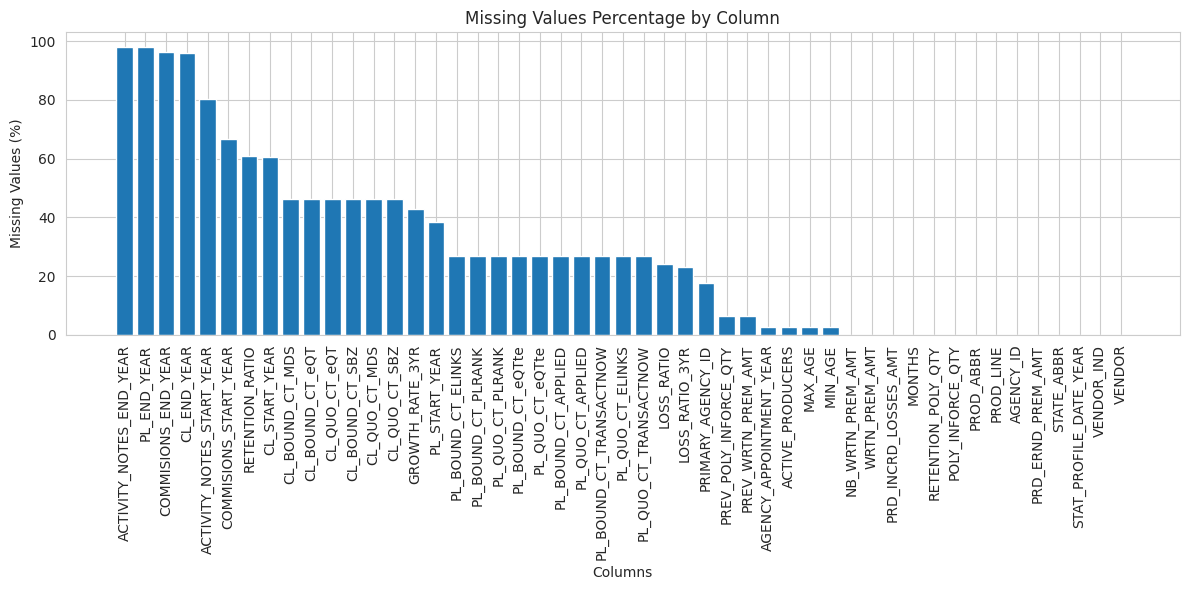

In [ ]:
missing_percent = (
    df_clean.isnull().mean() * 100
).sort_values(ascending=False)

plt.figure(figsize=(12, 6))

plt.bar(
    missing_percent.index,
    missing_percent.values
)

plt.title("Missing Values Percentage by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

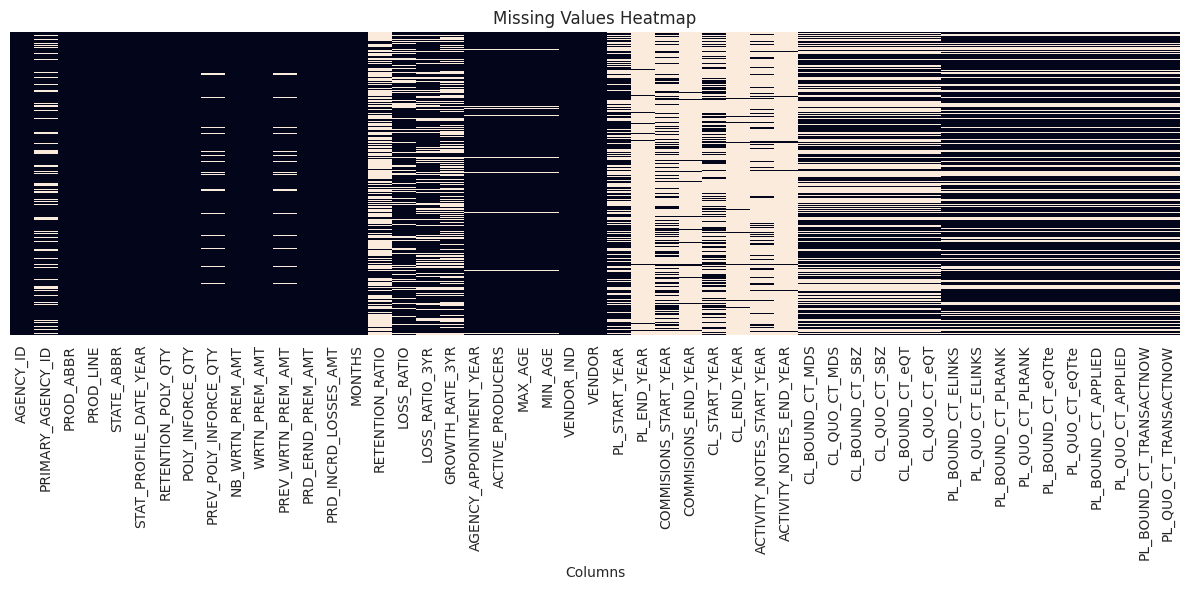

In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df_clean.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")

plt.tight_layout()
plt.show()

**14.Numeric Distribution**

In [ ]:
if "WRTN_PREM_AMT" in df_clean.columns:
    selected_numeric = "WRTN_PREM_AMT"
else:
    selected_numeric = numeric_columns[0]

print("Selected numeric column:", selected_numeric)

Selected numeric column: WRTN_PREM_AMT


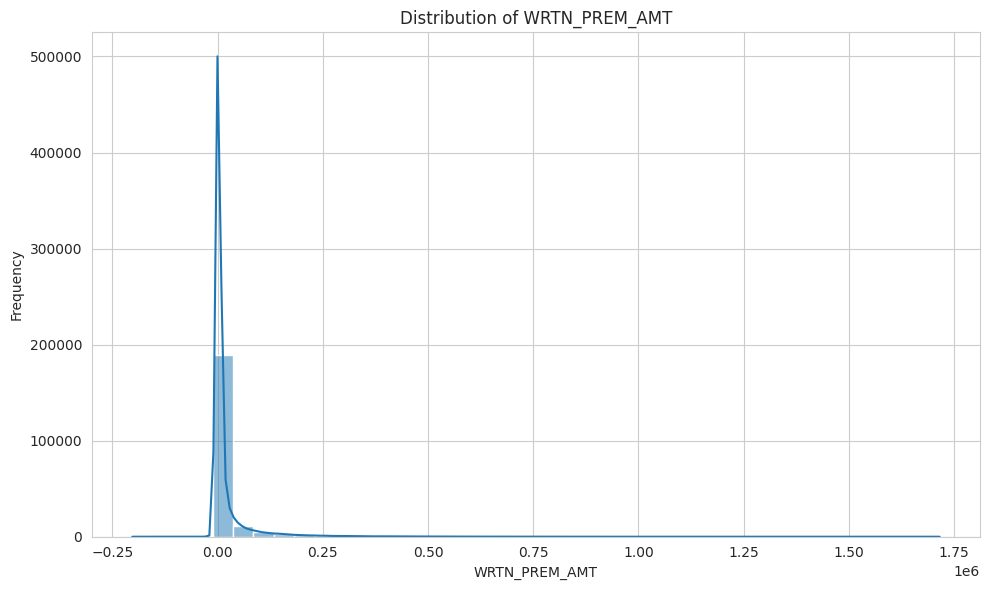

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean[selected_numeric].dropna(),
    bins=40,
    kde=True
)

plt.title(
    f"Distribution of {selected_numeric}"
)

plt.xlabel(selected_numeric)
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Boxplot for Outliers**

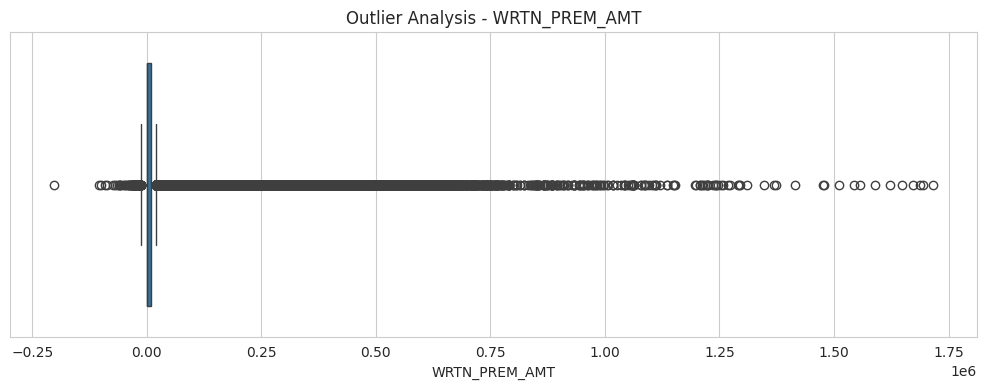

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df_clean[selected_numeric]
)

plt.title(
    f"Outlier Analysis - {selected_numeric}"
)

plt.xlabel(selected_numeric)

plt.tight_layout()
plt.show()

**15. Checking Negative Premium Values**

In [ ]:
if "WRTN_PREM_AMT" in df_clean.columns:

    negative_values = (
        df_clean["WRTN_PREM_AMT"] < 0
    ).sum()

    print(
        "Number of negative Written Premium values:",
        negative_values
    )

Number of negative Written Premium values: 4796


**16. Simple Data Quality Summary**

In [ ]:
total_rows = df_clean.shape[0]
total_columns = df_clean.shape[1]

total_missing = df_clean.isnull().sum().sum()

duplicate_count = df_clean.duplicated().sum()

high_missing_count = (
    (df_clean.isnull().mean() * 100) > 30
).sum()

summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Total Missing Values",
        "Duplicate Records",
        "High-Missing Columns",
        "Numeric Columns",
        "Categorical Columns"
    ],

    "Value": [
        total_rows,
        total_columns,
        total_missing,
        duplicate_count,
        high_missing_count,
        len(numeric_columns),
        len(categorical_columns)
    ]
})

summary

,Metric,Value
0,Total Rows,213328
1,Total Columns,49
2,Total Missing Values,2929965
3,Duplicate Records,0
4,High-Missing Columns,16
5,Numeric Columns,44
6,Categorical Columns,5


# Data Quality Risks

## 1. Hidden Missing Values

The dataset may contain special placeholder values such as 99999 that are not detected by normal null-value checks. These values should be treated as missing or unavailable information after confirming their business meaning.

## 2. Duplicate Records

Duplicate records were checked using the complete row values. Duplicate records can inflate counts and financial metrics, so they should be removed or investigated if found.

## 3. Categorical Inconsistency

Categorical columns were cleaned by removing leading/trailing spaces and standardizing text casing. This prevents the same category from being treated as multiple categories during future analysis.

## 4. Extreme Values and Outliers

The distribution and boxplot of the selected numeric metric should be examined for extreme values. Outliers may significantly affect averages and other statistical measures.

## 5. Negative Premium Values

Negative written premium values, if present, should not automatically be treated as errors. They may represent refunds, cancellations, adjustments, or corrections and should be validated with business stakeholders.

## 6. Zero-Heavy Variables

Some business metrics may contain a large number of zero values. Zero does not necessarily mean missing or incorrect, so the business meaning of these values should be verified.

# Conclusion

The Agency Performance dataset was successfully profiled to understand its structure, completeness, consistency, and reliability.

The analysis covered:

- Dataset structure and schema validation
- Data types and column names
- Data dictionary creation
- Missing-value analysis
- Hidden sentinel-value detection
- Duplicate-record analysis
- Categorical data cleaning
- Numerical distribution analysis
- Outlier detection
- Data quality risk identification

The analysis shows that simply checking NULL values is not sufficient for this dataset because special values such as `99999` may represent hidden missing information.

Categorical columns were standardized to improve consistency for future grouping and analysis.

The selected numerical variable was also analyzed using distribution and boxplot visualizations to identify skewness and extreme observations.

Overall, the dataset provides a suitable foundation for further business analysis, provided that the identified data-quality issues are validated and appropriately handled.

In [ ]:
print("=" * 70)
print("       AGENCY PERFORMANCE - DATA QUALITY SUMMARY")
print("=" * 70)

print(f"\nDataset Size        : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Numeric Columns     : {len(numeric_columns)}")
print(f"Categorical Columns : {len(categorical_columns)}")
print(f"Missing Values      : {df_clean.isnull().sum().sum():,}")
print(f"Duplicate Records   : {df_clean.duplicated().sum():,}")

print("\nAnalysis Completed:")
print("✓ Dataset profiling")
print("✓ Schema validation")
print("✓ Data dictionary")
print("✓ Missing-value analysis")
print("✓ Sentinel-value analysis")
print("✓ Duplicate analysis")
print("✓ Categorical cleaning")
print("✓ Numeric distribution analysis")
print("✓ Outlier analysis")
print("✓ Data quality assessment")

print("\nFinal Assessment:")
print("Dataset is ready for further analysis after")
print("appropriate validation of identified quality issues.")

       AGENCY PERFORMANCE - DATA QUALITY SUMMARY

Dataset Size        : 213,328 rows × 49 columns
Numeric Columns     : 44
Categorical Columns : 5
Missing Values      : 2,929,965
Duplicate Records   : 0

Analysis Completed:
✓ Dataset profiling
✓ Schema validation
✓ Data dictionary
✓ Missing-value analysis
✓ Sentinel-value analysis
✓ Duplicate analysis
✓ Categorical cleaning
✓ Numeric distribution analysis
✓ Outlier analysis
✓ Data quality assessment

Final Assessment:
Dataset is ready for further analysis after
appropriate validation of identified quality issues.
